<a href="https://colab.research.google.com/github/Krishna-Dhawangale/Resume-Screening-Machine-Learning-/blob/main/KNN_Resume_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ML_Data/AI_Resume_Screening.csv')
df.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [4]:
df.shape

(1000, 11)

In [5]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,274
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


Initial number of rows: 1000
Number of rows after removing duplicates: 1000
Number of duplicate rows removed: 0


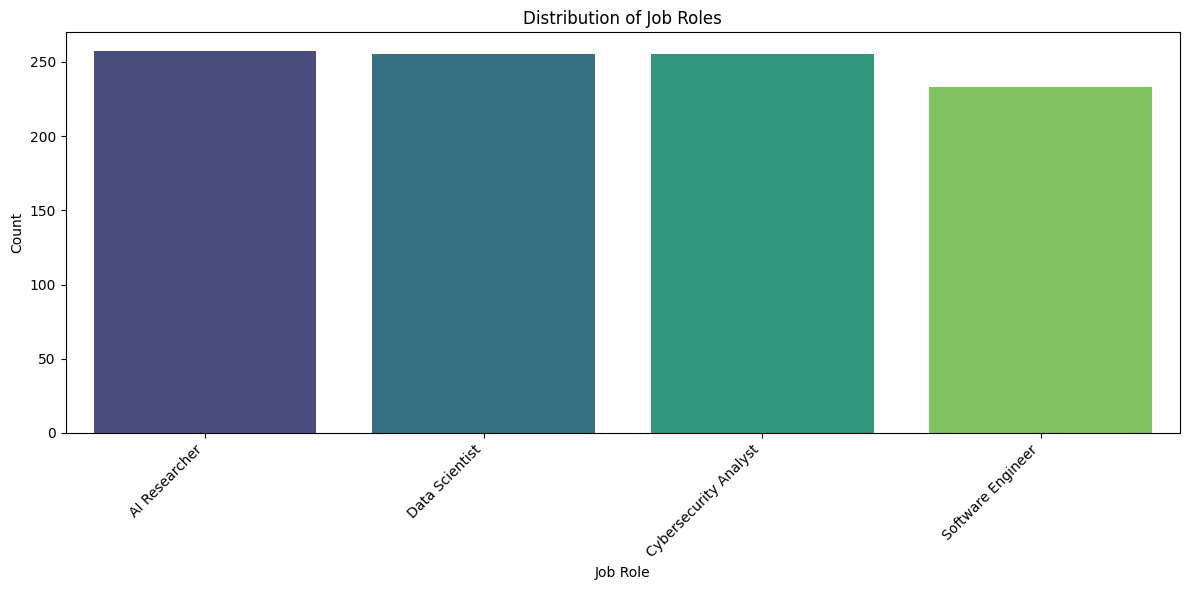

In [6]:
df_initial_shape = df.shape[0]
df.drop_duplicates(inplace=True)
df_new_shape = df.shape[0]
print(f"Initial number of rows: {df_initial_shape}")
print(f"Number of rows after removing duplicates: {df_new_shape}")
print(f"Number of duplicate rows removed: {df_initial_shape - df_new_shape}")

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Job Role', hue='Job Role', palette='viridis', legend=False)
plt.title('Distribution of Job Roles')
plt.xlabel('Job Role')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
import re

df['Skills'] = df['Skills'].str.lower()
df['Skills'] = df['Skills'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))
df['Skills'] = df['Skills'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

print("Preprocessing of 'Skills' column complete. Displaying first 5 rows:")
print(df['Skills'].head())

Preprocessing of 'Skills' column complete. Displaying first 5 rows:
0                       tensorflow nlp pytorch
1    deep learning machine learning python sql
2          ethical hacking cybersecurity linux
3                    python pytorch tensorflow
4                               sql react java
Name: Skills, dtype: object


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_skills_tfidf = tfidf_vectorizer.fit_transform(df['Skills'])

print("Shape of TF-IDF feature matrix:", X_skills_tfidf.shape)

Shape of TF-IDF feature matrix: (1000, 15)


In [15]:
from sklearn.model_selection import train_test_split

X = X_skills_tfidf
y = df['Recruiter Decision'] # Changed target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (800, 15)
Shape of X_test: (200, 15)
Shape of y_train: (800,)
Shape of y_test: (200,)


In [16]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

print("Initial KNN model trained successfully with n_neighbors=5.")

Initial KNN model trained successfully with n_neighbors=5.


In [17]:
from sklearn.metrics import accuracy_score

y_pred = knn_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of the initial KNN model: {accuracy:.4f}")

Accuracy of the initial KNN model: 0.7700


In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': range(1, 16)}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_n_neighbors = grid_search.best_params_['n_neighbors']
print(f"Best n_neighbors found: {best_n_neighbors}")

Best n_neighbors found: 8


In [19]:
optimized_knn_model = KNeighborsClassifier(n_neighbors=best_n_neighbors)
optimized_knn_model.fit(X_train, y_train)

y_pred_optimized = optimized_knn_model.predict(X_test)
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)

print(f"Accuracy of the optimized KNN model (n_neighbors={best_n_neighbors}): {accuracy_optimized:.4f}")

Accuracy of the optimized KNN model (n_neighbors=8): 0.7650


Classification Report for Initial KNN Model:
              precision    recall  f1-score   support

        Hire       0.77      0.99      0.87       154
      Reject       0.50      0.02      0.04        46

    accuracy                           0.77       200
   macro avg       0.64      0.51      0.46       200
weighted avg       0.71      0.77      0.68       200



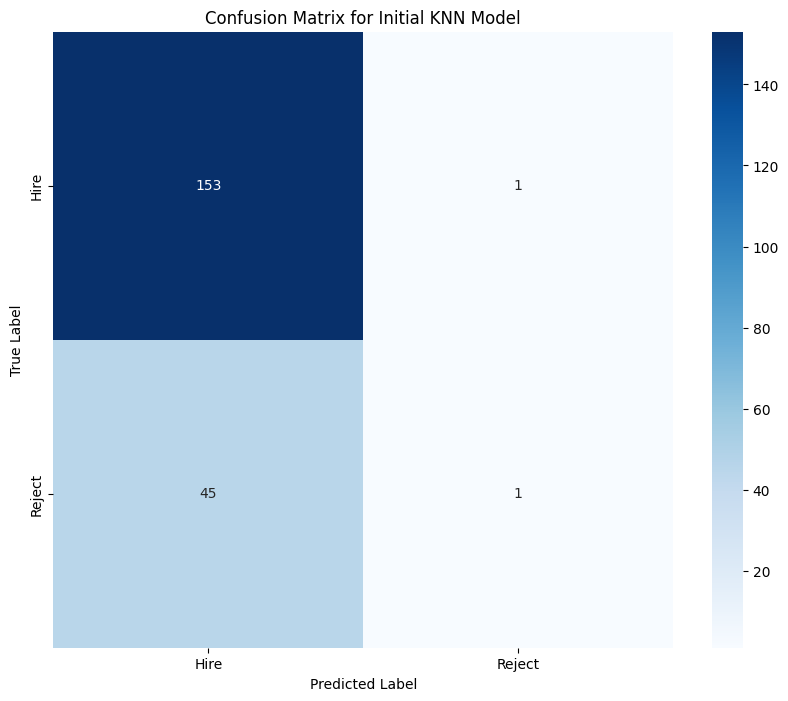

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Print the classification report
print("Classification Report for Initial KNN Model:")
print(classification_report(y_test, y_pred))

# 3. Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 4. Create a heatmap of the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=knn_model.classes_, yticklabels=knn_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Initial KNN Model')
plt.show()